In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [6]:
model = VGG16(weights="imagenet", include_top=False)
print("Model ready")


Model ready


In [2]:
def extract_feature(image_path):
    img = cv2.imread(image_path)
    
    if img is None:
        return None   # skip bad image
    
    img = cv2.resize(img, (224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    
    feature = model.predict(img)
    return feature.flatten()



In [7]:
base_path = "../data/images/dataset_updated/training_set"

features = []
image_paths = []

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)
    
    for img_name in os.listdir(category_path)[:50]:
        path = os.path.join(category_path, img_name)
        f = extract_feature(path)
        
        if f is not None:   # only keep valid images
            features.append(f)
            image_paths.append(path)

print("Total images processed:", len(features))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
from sklearn.metrics.pairwise import cosine_similarity


In [9]:
def recommend_art(index, top_n=5):
    query_feature = features[index]
    
    similarities = cosine_similarity(
        [query_feature], features
    )[0]
    
    similar_indices = similarities.argsort()[::-1][1:top_n+1]
    
    return similar_indices


In [15]:
test_index = 1  # first artwork
recommended = recommend_art(test_index)

print(recommended)


[ 71  78  14 101  17]


In [26]:
import matplotlib.pyplot as plt
import cv2

def show_recommendations(index, recommended_indices):
    # show selected image
    img = cv2.imread(image_paths[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title("Selected Artwork")
    plt.axis("off")
    plt.show()
    
    # show recommended images
    for i in recommended_indices:
        img = cv2.imread(image_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(3,3))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


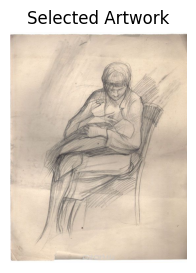

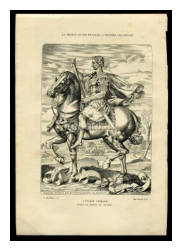

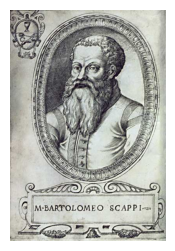

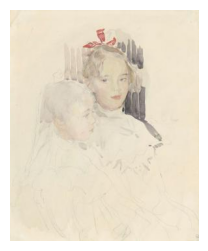

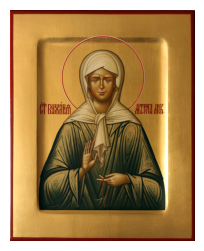

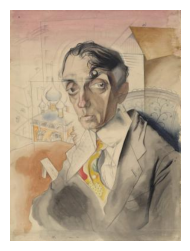

In [27]:
show_recommendations(test_index, recommended)


In [18]:
moods = {
    "calm": ["blue", "green", "soft"],
    "energetic": ["red", "yellow", "bright"],
    "dark": ["black", "grey", "deep"],
    "romantic": ["pink", "warm", "soft"],
    "chaotic": ["contrast", "sharp"]
}


In [1]:
from sklearn.cluster import KMeans
import cv2
import os

def get_dominant_color(image_path):

    # Get current file directory (app folder)
    BASE_DIR = os.path.dirname(__file__)

    # Go one level up to project root, then to image
    full_path = os.path.join(BASE_DIR, "..", image_path)

    # Read image
    img = cv2.imread(full_path)

    # Safety check (prevents Streamlit crash)
    if img is None:
        print("ERROR loading:", full_path)
        return [0, 0, 0]

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.reshape((-1, 3))

    kmeans = KMeans(n_clusters=1, n_init=10)
    kmeans.fit(img)

    return kmeans.cluster_centers_[0]

In [20]:
def color_to_mood(color):
    r, g, b = color
    
    if b > r and b > g:
        return "calm"
    if r > 150 and g < 100:
        return "energetic"
    if r < 80 and g < 80 and b < 80:
        return "dark"
    return "neutral"


In [24]:
def recommend_with_mood(index, user_mood, top_n=5):
    base_similar = recommend_art(index, top_n=20)
    
    mood_filtered = []
    
    for i in base_similar:
        color = get_dominant_color(image_paths[i])
        img_mood = color_to_mood(color)
        
        if img_mood == user_mood or img_mood == "neutral":
            mood_filtered.append(i)
        
        if len(mood_filtered) == top_n:
            break
    
    return mood_filtered


In [25]:
recommend_with_mood(0, "calm")


[np.int64(63), np.int64(72), np.int64(75), np.int64(62), np.int64(88)]

In [28]:
import pickle

with open("../model/features.pkl", "wb") as f:
    pickle.dump(features, f)

with open("../model/image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)
